### Load Data

In [19]:
import polars as pl
import duckdb

df = pl.read_parquet("data/uc-faculty.parquet")
duckdb.connect()


### Basic Data Information


In [20]:
df.describe()

statistic,year,campus,last_name,first_name,title_name,department,gross_pay,base_pay,overtime_pay,other_pay
str,f64,str,str,str,str,str,f64,f64,f64,f64
"""count""",3.660661e6,"""3660661""","""3660661""","""3660660""","""3660657""","""3660320""",3.660661e6,3.660661e6,3.660661e6,3.660661e6
"""null_count""",0.0,"""0""","""0""","""1""","""4""","""341""",0.0,0.0,0.0,0.0
"""mean""",2018.764224,null,null,null,null,null,56705.176119,48504.964208,847.00437,7353.209968
"""std""",3.458144,null,null,null,null,null,78820.283732,55530.470437,3942.074732,39005.584722
"""min""",2013.0,null,""" """,""" ""","""9964 - no description found""",null,1.0,-385300.0,-49939.0,-345255.0
"""25%""",2016.0,null,null,null,null,null,5166.0,4508.0,0.0,0.0
"""50%""",2019.0,null,null,null,null,null,34225.0,31786.0,0.0,0.0
"""75%""",2022.0,null,null,null,null,null,76860.0,71906.0,0.0,2500.0
"""max""",2024.0,null,"""zyzik ""","""ângela""","""zone mech""",null,7.061667e6,1.965054e6,298933.0,6.761667e6


In [21]:
df.head()

year,campus,last_name,first_name,title_name,department,gross_pay,base_pay,overtime_pay,other_pay
i16,cat,str,str,str,cat,i32,i32,i32,i32
2024,"""asucla""","""abbassi""","""pouria""","""dir exec""","""executive director""",390489,356085,0,34405
2024,"""asucla""","""mehdian""","""kamran""","""dir""","""systems development""",247343,236450,0,10893
2024,"""asucla""","""baker""","""donna""","""dir""","""financial planning & analysis""",243072,232372,0,10700
2024,"""asucla""","""moyer""","""michelle""","""dir""","""human resources""",241336,231051,0,10285
2024,"""asucla""","""bolton""","""cynthia""","""dir""","""rest operations""",182084,174324,0,7760


### Basic Data Filters
Table name for SQL statements is faculty_salaries

In [22]:
# Min base_pay must be higher than minimum wage full time
# To try and only have educational faculty we fuzzy match on prof, lect, instr, and adj.

filter_str = """
SELECT *, CONCAT(title_name, department) as job_dep
FROM df
WHERE 
    ( -- Basic Filters
    job_dep ILIKE '%prof%'
    OR job_dep ILIKE '%lect%'
    OR job_dep ILIKE '%adj%'
    OR job_dep ILIKE '%instr%'
    ) AND 
    ( -- Advanced Filters
    job_dep NOT ILIKE '%electrn%'
    AND job_dep NOT ILIKE '%profl%'
    AND job_dep NOT ILIKE '%maintenance%'
    AND job_dep NOT ILIKE '%collection%'
    AND job_dep NOT ILIKE '%part time%'
    AND job_dep NOT ILIKE '%budget%'
    AND job_dep NOT ILIKE '%instructional design%'
    AND job_dep NOT ILIKE '%elected%'
    AND job_dep NOT ILIKE '%adminstr%'
    AND job_dep NOT ILIKE '%services%'
    AND job_dep NOT ILIKE '%property%'
    AND job_dep NOT ILIKE '%recall%'
    AND job_dep NOT ILIKE '%electrocardiograph%'
    AND job_dep NOT ILIKE '%cntrl tchn%'
    ) AND 
    -- Min Pay
    base_pay >= 35152
"""

df = duckdb.sql(f"""
    {filter_str}
    """).pl()


duckdb.sql(f"""
CREATE OR REPLACE TABLE faculty_salaries AS
    SELECT *
    FROM df
    """)


Data info after filter

In [23]:
df.describe()

statistic,year,campus,last_name,first_name,title_name,department,gross_pay,base_pay,overtime_pay,other_pay,job_dep
str,f64,str,str,str,str,str,f64,f64,f64,f64,str
"""count""",258814.0,"""258814""","""258814""","""258814""","""258814""","""258810""",258814.0,258814.0,258814.0,258814.0,"""258814"""
"""null_count""",0.0,"""0""","""0""","""0""","""0""","""4""",0.0,0.0,0.0,0.0,"""0"""
"""mean""",2018.941189,null,null,null,null,null,204508.517936,137502.429386,89.10681,66916.982288,null
"""std""",3.424275,null,null,null,null,null,154318.903095,69416.438661,1275.812339,117534.004209,null
"""min""",2013.0,"""berkeley""","""****""",""" aamir""","""acad achievement cnslr 3""",""" """,27496.0,35152.0,-1975.0,-345255.0,"""acad achievement cnslr 3contin…"
"""25%""",2016.0,null,null,null,null,null,103575.0,89000.0,0.0,448.0,null
"""50%""",2019.0,null,null,null,null,null,165342.0,125943.0,0.0,24222.0,null
"""75%""",2022.0,null,null,null,null,null,259826.0,172817.0,0.0,81999.0,null
"""max""",2024.0,"""ucop""","""zyzik ""","""zyrene""","""writer sr""","""writing programs """,3.974061e6,838117.0,94536.0,3.695451e6,"""writer srarts and lectures off…"


In [24]:
df.head()

year,campus,last_name,first_name,title_name,department,gross_pay,base_pay,overtime_pay,other_pay,job_dep
i16,str,str,str,str,str,i32,i32,i32,i32,str
2024,"""berkeley""","""malmendier""","""ulrike""","""prof-ay-b/e/e""","""haas core programs""",730483,548817,0,181667,"""prof-ay-b/e/ehaas core program…"
2024,"""berkeley""","""chatman""","""jennifer""","""prof-ay-b/e/e""","""haas core programs""",718700,445800,0,272900,"""prof-ay-b/e/ehaas core program…"
2024,"""berkeley""","""yaghi""","""omar""","""prof-ay""","""dept of chemistry""",690298,441667,0,248631,"""prof-aydept of chemistry"""
2024,"""berkeley""","""isacoff""","""ehud""","""prof-ay""","""molecular & cell biology""",680880,481058,0,199822,"""prof-aymolecular & cell biolog…"
2024,"""berkeley""","""farber""","""daniel""","""prof-ay-law""","""law""",677222,478333,0,198888,"""prof-ay-lawlaw"""


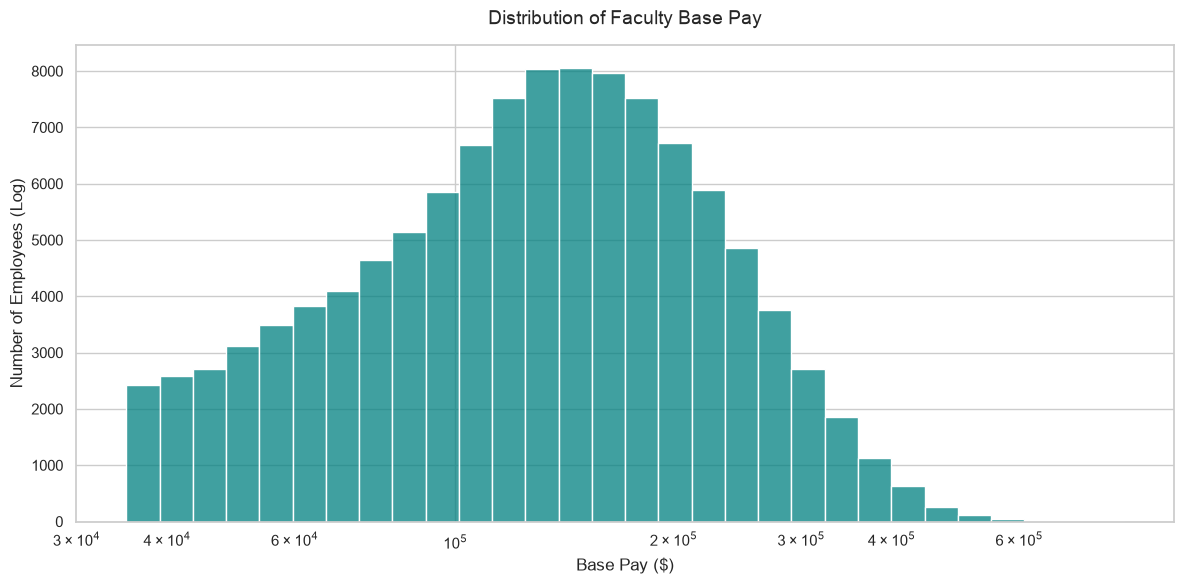

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

pay_df = duckdb.sql("""
SELECT COUNT(*) as count, base_pay AS pay
FROM faculty_salaries
GROUP BY pay
ORDER BY count DESC, pay ASC
""").pl()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Create the histogram (bar graph of the distribution)
sns.histplot(
    data=pay_df, 
    x="pay", 
    bins=30,
    log_scale=True,
    color="teal", 
    edgecolor="white"
)

plt.title("Distribution of Faculty Base Pay", fontsize=14, pad=15)
plt.xlabel("Base Pay ($)", fontsize=12)
plt.ylabel("Number of Employees (Log)", fontsize=12)

ax = plt.gca()

plt.tight_layout()
plt.show()

## Department Cleaning

### Amount of Existing Departments & Titles


In [26]:
duckdb.sql("""
SELECT COUNT(DISTINCT department) AS unique_departments
FROM faculty_salaries
           """).pl()

unique_departments
i64
2908


In [27]:
duckdb.sql("""
SELECT COUNT(DISTINCT title_name) AS unique_titles
FROM faculty_salaries
           """).pl()

unique_titles
i64
877


In [28]:
pl.Config.set_tbl_rows(20)

duckdb.sql("""
SELECT COUNT(department) AS count, department, 
FROM faculty_salaries
GROUP BY department
ORDER BY count DESC
LIMIT 20
           """).pl()

count,department
i64,str
4496,"""medicine"""
3912,"""mathematics"""
2750,"""pediatrics"""
2555,"""history"""
2497,"""economics"""
2323,"""psychology"""
2311,"""english"""
2031,"""political science"""
1916,"""sociology"""


# Depatment Buckets 

## Existing Department Buckets

### Calpoly
* Engineering
* Science & Math
* Business
* Agriculture, Food, & Animal Science
* Noyce 
* Architecture
* Liberal Arts

### Faculty Pay DB
* Languages
* Communication
* English
* Education
* History
* Philosophy
* Architecture
* Social Sciences
* Public Administration
* Math
* Psychology
* Agriculture
* Biology
* Physics
* Computer Science
* Engineering
* Economics
* Business
* Finance
* Law

## Proposed Department Buckets
* Engineering 
* Computer Science
* Science & Mathematics
* Medicine & Heath Sciences
* Business, Economics & Finance
* Agriculture, Food & Animal
* Architecture & Environmental Design
* Humanities & Languages
* Social Sciences & Communication
* Education & Public Administration

In [29]:
pl.Config.set_tbl_rows(20)

duckdb.sql("""
SELECT COUNT(department) AS count, department, 
FROM faculty_salaries
GROUP BY department
ORDER BY count DESC
LIMIT 20
           """).pl()
pl.Config.set_tbl_rows(5)

polars.config.Config

In [30]:
duckdb.sql("""
SELECT DISTINCT department
FROM faculty_salaries
           """).pl().write_csv("Departments.csv")

### Creating The Proposed Buckets

In [31]:
bucket_sql = """
SELECT *,
CASE
    WHEN 
        department ILIKE '%computer%' 
        OR department ILIKE '%comp sci%'
        OR department ILIKE '%cmptr sci%'
        OR department ILIKE '%computing%'
        OR department ILIKE '%software%'
        OR department ILIKE '%informatics%'
        OR department ILIKE '%cyber%'
        OR department ILIKE '%data science%'
        OR department ILIKE '%information studies%'
        OR department ILIKE '%school of info%'
        
    THEN 'Computer Science'
    
    WHEN 
        department ILIKE '%medicine%'
        OR department ILIKE '%surgery%'
        OR department ILIKE '%vm:%'
        OR department ILIKE '%med:%'
        OR department ILIKE '%!_%' ESCAPE '!' -- For some reason all of the _'s for UC's are medicine or health lol
        OR department ILIKE '%nurs%'
        OR department ILIKE '%dentistry%'
        OR department ILIKE '%pharma%'
        OR department ILIKE '%gynecology%'
        OR department ILIKE '%urology%'
        OR department ILIKE '%oncology%'
        OR department ILIKE '%family med%'
        OR department ILIKE '%radiation%'
        OR department ILIKE '%ophthalmology%'
        OR department ILIKE '%pathology%'
        OR department ILIKE '%peds%'
        OR department ILIKE '%dermatology%'
        OR department ILIKE '%pediatrics%'
        OR department ILIKE '%anesthesiology%'
        OR department ILIKE '%optometry%'
        OR department ILIKE '%psychiatry%'
        OR department ILIKE '%emerg med%'
        OR department ILIKE '%radiolog%'
        OR department ILIKE '%radiation%'
        OR department ILIKE '%anesthes%'
        OR department ILIKE '%ob/gyn%'
        OR department ILIKE '%ambulatory%'
        OR department ILIKE '%electronic health record%'
        OR department ILIKE '%electrocardiology%'
        OR department ILIKE '%epidemiology%'
        OR department ILIKE '%otolaryngology%'
        OR department ILIKE '%hematology%'
        OR department ILIKE '%school of public health%'
        OR department ILIKE '%health policy and management%'
        OR department ILIKE '%health sciences%'
        OR department ILIKE '%lppi: instr & research%'
    THEN 'Medicine & Health Sciences'
    
    WHEN 
        department ILIKE '%business%'
        OR department ILIKE '%econ%'
        OR department ILIKE '%finance%'
        OR department ILIKE '%of managemen%'
        OR department ILIKE '%haas core%'
    THEN 'Business, Economics & Finance'
    
    WHEN
        department ILIKE '%engineer%'
        OR department ILIKE '%engr%'
        OR department ILIKE '%mech%'
        OR department ILIKE '%civil%'
        OR department ILIKE '%areo%'
        OR department ILIKE '%electric%'
        OR department ILIKE '%soe-ams%'
        OR department ILIKE '%chemical%'
        OR department ILIKE '%industrial%'
        OR department ILIKE '%material%'
        OR department ILIKE '%soece-ee-tm-cm%'
    THEN 'Engineering'
    
    WHEN
        department ILIKE '%math%'
        OR department ILIKE '%stat%'
        OR department ILIKE '%statistics%'
        OR department ILIKE '%bio%'
        OR department ILIKE '%neuro%'
        OR department ILIKE '%phys%'
        OR department ILIKE '%physics%'
        OR department ILIKE '%astro%'
        OR department ILIKE '%chem%'
        OR department ILIKE '%sio dep%'
        OR department ILIKE '%molecular, cell%'
        OR department ILIKE '%earth%'
        OR department ILIKE '%oceanic%'
        OR department ILIKE '%ecology%'
        OR department ILIKE '%genetics%'
        OR department ILIKE '%igpp%'
        OR department ILIKE '%geosciences%'
    THEN 'Science & Mathematics'
    
    WHEN
        department ILIKE '%plant science%'
        OR department ILIKE '%agriculture%'
        OR department ILIKE '%espm%'
        OR department ILIKE '%nutrition%'
        OR department ILIKE '%inst of environment and sustai%'
        OR department ILIKE '%animal%'
        OR department ILIKE '%food science%'
        OR department ILIKE '%food safety%'
    THEN 'Agriculture, Food & Animal'
    
    WHEN
        department ILIKE '%architec%'
        OR department ILIKE '%planning%'
        OR department ILIKE '%urban%'
        OR department ILIKE '%landscape arch%'
        OR department ILIKE '%environmental%'
    THEN 'Architecture & Environmental Design'
    
    WHEN
        department ILIKE '%language%'
        OR department ILIKE '%linguistics%'
        OR department ILIKE '%humanities%'
        OR department ILIKE '%english%'
        OR department ILIKE '%literature%'
        OR department ILIKE '%writing%'
        OR department ILIKE '%history%'
        OR department ILIKE '%philosophy%'
        OR department ILIKE '%french%'
        OR department ILIKE '%spanish%'
        OR department ILIKE '%german%'
        OR department ILIKE '%japanese%'
        OR department ILIKE '%dance%'
        OR department ILIKE '%african%'
        OR department ILIKE '%music%'
        OR department ILIKE '%division of arts%'
        OR department ILIKE '%classics%'
        OR department ILIKE '%film%'
        OR department ILIKE '%visual arts%'
        OR department ILIKE '%theatre%'
        OR department ILIKE '%religious%'
        OR department ILIKE '%theater%'
        OR department ILIKE '%asian lang%'
        OR department ILIKE '%eastern lang%'
        OR department ILIKE '%world arts%'
        OR department ILIKE '%southeast asian%'
        OR department ILIKE '%drama department%'
        OR department ILIKE '%department of chicana%'
        OR department ILIKE '%asian-american%'
        OR department ILIKE '%asian%'
        OR department ILIKE '%studio art%'
        OR department ILIKE '%art%'
        OR department ILIKE '%design program%'
        OR department ILIKE '%rhetoric%'
        OR department ILIKE '%near eastern%'
        OR department ILIKE '%chicano%'
        OR department ILIKE '%department of design%'
        OR department ILIKE '%media%'
        OR department ILIKE '%drama%'
        OR department ILIKE '%hispanic%'
    THEN 'Humanities & Languages'
    
    WHEN
        department ILIKE '%anthropology%'
        OR department ILIKE '%social science%'
        OR department ILIKE '%sociology%'
        OR department ILIKE '%political science%'
        OR department ILIKE '%ethnic stud%'
        OR department ILIKE '%psychology%'
        OR department ILIKE '%psychological%'
        OR department ILIKE '%cognitive science%'
        OR department ILIKE '%comm%'
        OR department ILIKE '%child%'
        OR department ILIKE '%geography%'
        OR department ILIKE '%human ecology%'
        OR department ILIKE '%social welfare%'
        OR department ILIKE '%global & international studies%'
        OR department ILIKE '%african am studies%'
        OR department ILIKE '%black studies%'
    THEN 'Social Sciences & Communication'
    
    WHEN
        department ILIKE '%education%'
        OR department ILIKE '%public policy%'
        OR department ILIKE '%policy&strategy%'
        OR department ILIKE 'jd program'
        OR department ILIKE '%law%'
        OR department ILIKE '%legal%'
        OR department ILIKE '%journalism%'
        OR department ILIKE '%teaching%'
    THEN 'Education & Public Administration'
    
    ELSE 'Other'
END AS dep_bucket 
FROM faculty_salaries
"""

duckdb.sql(f"""
CREATE OR REPLACE TABLE faculty_salaries AS
{bucket_sql}
""")

In [32]:
# Remove UnBucketable Departments
duckdb.sql("""
DELETE FROM faculty_salaries
WHERE department IN (
    'continuing & professional ed.',
    'faculty',
    'intellectual prop & indus spon',
    'edu/instruction & research',
    'university - davis',
    'elect eng div operations',
    'mae department accounts',
    'administration',
    'merage/instruction & academic',
    'the preuss school',
    'public health administration',
    'instructional development',
    'geffen academy at ucla',
    'gspp department ops',
    'dean-school of env sci & mgmt',
    'continuing & professional ed. ',
    'continuing and professional ed',
    'structural system facility',
    'chancellor ucsf',
    'oid instructional improvement',
    'tep',
    'sph administration            ',
    'information technology svcs',
    'ofc of instructional developme',
    'geffen academy at ucla        ',
    '',
)
""")

In [33]:
pl.Config.set_tbl_rows(11)

# How many departments are accounted for in each bucket
duckdb.sql("""
SELECT COUNT(DISTINCT department) AS count, dep_bucket
FROM faculty_salaries
GROUP BY dep_bucket
ORDER BY count DESC
           """).pl()

count,dep_bucket
i64,str
1059,"""Medicine & Health Sciences"""
850,"""Other"""
322,"""Humanities & Languages"""
242,"""Science & Mathematics"""
136,"""Engineering"""
77,"""Social Sciences & Communicatio…"
66,"""Education & Public Administrat…"
40,"""Computer Science"""
36,"""Architecture & Environmental D…"


In [34]:
pl.Config.set_tbl_rows(71)
duckdb.sql("""
SELECT COUNT(*) as count, department
FROM faculty_salaries
WHERE dep_bucket = 'Other'
GROUP BY department
HAVING count > 50
ORDER BY count DESC
-- LIMIT 11
           """).pl()

count,department
i64,str
96,"""institute for society and gene"""
95,"""gender and women's studies"""
94,"""bus infrast admin prgm srv sup"""
92,"""edu/instruction & research """
90,"""college of creative studies"""
89,"""oid instructional technology"""
87,"""politics"""
87,"""land air & water resources"""
87,"""womens studies program"""
